# RQ1: Traceable Explanation Quality

**Research Question:** To what extent can the Screener-Reasoner framework produce traceable,
evidence-grounded explanations for anomalous log sessions, as measured by structured output
compliance, evidence citation coverage, and human-evaluated explanation quality?

**Context:** Hybrid screener-reasoner uses a two-stage framework: (1) a linaer self attention-based **Screener** detects
anomalies with near-perfect accuracy, then (2) an LLM **Reasoner** (GPT-5.1) generates
structured, evidence-grounded explanations for each detected anomaly. RQ1 evaluates the
end-to-end quality of these explanations across two production-scale log datasets.

**Evaluation Dimensions:**
- **Structured output compliance**: Every explanation must produce valid JSON matching the
  trace schema (3 typed claims with evidence citations)
- **Verification pass rate**: 9 automated checks per explanation (evidence ID validity,
  keyword grounding, JSON structure, evidence coverage)
- **Signature taxonomy**: Canonical anomaly signatures discovered across all sessions
- **Human evaluation (n=200)**: Correctness, Completeness, Evidence Grounding (1-5),
  Actionability (Y/N) -- 100 samples per dataset, stratified by signature

**Data Sources (GPT-5.1 full runs):**
- BGL: `explanations_BGL_20260301_112519.jsonl` (6,295 sessions, 360 signatures)
- HDFS: `explanations_HDFS_20260303_162016.jsonl` (2,527 sessions, 168 signatures)
- Human ratings: `human_eval_GPT51_ratings.json` (200 ratings: 100 BGL + 100 HDFS)

## 1. Setup & Data Loading

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict

PROJECT_ROOT = Path('..').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_HDFS_DIR = PROJECT_ROOT / 'results_HDFS'

BGL_JSONL = RESULTS_DIR / 'explanations_BGL_20260313_002116.jsonl'
HDFS_JSONL = RESULTS_HDFS_DIR / 'explanations_HDFS_20260311_230513.jsonl'
BGL_METRICS = RESULTS_DIR / 'explanations_BGL_20260313_002116.metrics.json'
HDFS_METRICS = RESULTS_HDFS_DIR / 'explanations_HDFS_20260311_230513.metrics.json'
HUMAN_EVAL = RESULTS_DIR / 'human_eval_postfix_ratings.json'

print(f'BGL JSONL exists:   {BGL_JSONL.exists()}')
print(f'HDFS JSONL exists:  {HDFS_JSONL.exists()}')
print(f'Human eval exists:  {HUMAN_EVAL.exists()}')


BGL JSONL exists:   True
HDFS JSONL exists:  True
Human eval exists:  True


In [2]:
# Load metrics JSONs
with open(BGL_METRICS) as f:
    bgl_metrics = json.load(f)
with open(HDFS_METRICS) as f:
    hdfs_metrics = json.load(f)

# Load all JSONL records
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    return records

bgl_records = load_jsonl(BGL_JSONL)
hdfs_records = load_jsonl(HDFS_JSONL)
print(f'BGL:  {len(bgl_records):,} records loaded')
print(f'HDFS: {len(hdfs_records):,} records loaded')

# Load human eval
with open(HUMAN_EVAL) as f:
    human_eval = json.load(f)
he_ratings = human_eval['ratings']
print(f'Human eval: {len(he_ratings)} ratings')

BGL:  5,850 records loaded
HDFS: 2,527 records loaded
Human eval: 100 ratings


## 2. Screener Detection Baseline

The Linformer-based Screener is the prerequisite for explanation generation.
These numbers establish detection accuracy as a **precondition**, not a contribution of RQ1.

In [3]:
# Screener test-set performance (from BGL_screener.ipynb and HDFS_screener.ipynb)
# These are hardcoded from the screener evaluation notebooks.
screener_perf = {
    'BGL': {
        'test_sessions': 71_220,
        'normal_p': 0.99979, 'normal_r': 0.99985, 'normal_f1': 0.99982,
        'anomaly_p': 0.99829, 'anomaly_r': 0.99761, 'anomaly_f1': 0.99795,
        'accuracy': 0.99966, 'macro_f1': 0.99888, 'weighted_f1': 0.99966,
        'TP': 5840, 'TN': 65356, 'FP': 10, 'FN': 14,
    },
    'HDFS': {
        'test_sessions': 86_260,
        'normal_p': 0.99952, 'normal_r': 0.99992, 'normal_f1': 0.99972,
        'anomaly_p': 0.99719, 'anomaly_r': 0.98416, 'anomaly_f1': 0.99064,
        'accuracy': 0.99946, 'macro_f1': 0.99518, 'weighted_f1': 0.99945,
        'TP': 2486, 'TN': 83727, 'FP': 7, 'FN': 40,
    }
}

# Table 1: Screener Detection Performance
print('Table 1: Screener Detection Performance (Linformer, test set)')
print('=' * 72)
print(f'{"Metric":<30} {"BGL":>18} {"HDFS":>18}')
print('-' * 72)
print(f'{"Test sessions":<30} {screener_perf["BGL"]["test_sessions"]:>18,} {screener_perf["HDFS"]["test_sessions"]:>18,}')
print(f'{"":<30} {"":>18} {"":>18}')
print(f'{"Normal Precision":<30} {screener_perf["BGL"]["normal_p"]:>18.5f} {screener_perf["HDFS"]["normal_p"]:>18.5f}')
print(f'{"Normal Recall":<30} {screener_perf["BGL"]["normal_r"]:>18.5f} {screener_perf["HDFS"]["normal_r"]:>18.5f}')
print(f'{"Normal F1":<30} {screener_perf["BGL"]["normal_f1"]:>18.5f} {screener_perf["HDFS"]["normal_f1"]:>18.5f}')
print(f'{"":<30} {"":>18} {"":>18}')
print(f'{"Anomaly Precision":<30} {screener_perf["BGL"]["anomaly_p"]:>18.5f} {screener_perf["HDFS"]["anomaly_p"]:>18.5f}')
print(f'{"Anomaly Recall":<30} {screener_perf["BGL"]["anomaly_r"]:>18.5f} {screener_perf["HDFS"]["anomaly_r"]:>18.5f}')
print(f'{"Anomaly F1":<30} {screener_perf["BGL"]["anomaly_f1"]:>18.5f} {screener_perf["HDFS"]["anomaly_f1"]:>18.5f}')
print(f'{"":<30} {"":>18} {"":>18}')
print(f'{"Accuracy":<30} {screener_perf["BGL"]["accuracy"]:>18.5f} {screener_perf["HDFS"]["accuracy"]:>18.5f}')
print(f'{"Macro F1":<30} {screener_perf["BGL"]["macro_f1"]:>18.5f} {screener_perf["HDFS"]["macro_f1"]:>18.5f}')
print('=' * 72)

Table 1: Screener Detection Performance (Linformer, test set)
Metric                                        BGL               HDFS
------------------------------------------------------------------------
Test sessions                              71,220             86,260
                                                                    
Normal Precision                          0.99979            0.99952
Normal Recall                             0.99985            0.99992
Normal F1                                 0.99982            0.99972
                                                                    
Anomaly Precision                         0.99829            0.99719
Anomaly Recall                            0.99761            0.98416
Anomaly F1                                0.99795            0.99064
                                                                    
Accuracy                                  0.99966            0.99946
Macro F1                             

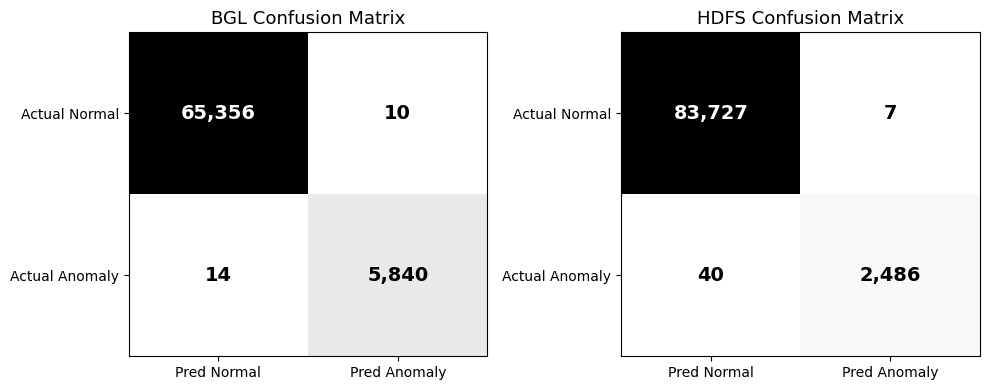

Saved: results/rq1_confusion_matrices.png


In [4]:
# Figure 1: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ds in zip(axes, ['BGL', 'HDFS']):
    s = screener_perf[ds]
    cm = np.array([[s['TN'], s['FP']], [s['FN'], s['TP']]])
    im = ax.imshow(cm, cmap='gray_r', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'], fontsize=10)
    ax.set_yticklabels(['Actual Normal', 'Actual Anomaly'], fontsize=10)
    ax.set_title(f'{ds} Confusion Matrix', fontsize=13)
    # Annotate cells
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq1_confusion_matrices.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results/rq1_confusion_matrices.png')

## 3. Full-Run Pipeline Summary

Production-scale explanation generation: the Reasoner (GPT-5.1) generates structured
explanations for every anomaly detected by the Screener.

In [5]:
# Table 2: Full-Run Pipeline Summary
def fmt(n):
    return f'{n:,}' if isinstance(n, int) else f'{n:,.1f}' if n > 100 else f'{n:.4f}'

b, h = bgl_metrics, hdfs_metrics

bgl_vpass = b['verification']['passed']
hdfs_vpass = h['verification']['passed']
bgl_total = b['counts']['total_anomalies']
hdfs_total = h['counts']['total_anomalies']

print('Table 2: Explanation Pipeline Full-Run Summary (GPT-5.1)')
print('=' * 72)
print(f'{"Metric":<35} {"BGL":>15} {"HDFS":>15}')
print('-' * 72)
print(f'{"Anomalies explained":<35} {bgl_total:>15,} {hdfs_total:>15,}')
print(f'{"Successful":<35} {b["counts"]["successful"]:>15,} {h["counts"]["successful"]:>15,}')
print(f'{"Errors":<35} {b["counts"]["errors"]:>15,} {h["counts"]["errors"]:>15,}')
print(f'{"Verification passed":<35} {bgl_vpass:>15,} {hdfs_vpass:>15,}')
print(f'{"Verification pass rate":<35} {bgl_vpass/bgl_total*100:>14.2f}% {hdfs_vpass/hdfs_total*100:>14.2f}%')
print(f'{"":<35} {"":>15} {"":>15}')
print(f'{"Unique signatures":<35} {len(b["signatures"]):>15,} {len(h["signatures"]):>15,}')
print(f'{"":<35} {"":>15} {"":>15}')
print(f'{"Total tokens":<35} {b["tokens"]["total"]:>15,} {h["tokens"]["total"]:>15,}')
print(f'{"Avg tokens/session":<35} {b["tokens"]["avg"]:>15,.0f} {h["tokens"]["avg"]:>15,.0f}')
print(f'{"":<35} {"":>15} {"":>15}')
print(f'{"Avg latency (ms)":<35} {b["latency"]["avg_ms"]:>15,.0f} {h["latency"]["avg_ms"]:>15,.0f}')
print(f'{"P95 latency (ms)":<35} {b["latency"]["p95_ms"]:>15,.0f} {h["latency"]["p95_ms"]:>15,.0f}')
print(f'{"Total wall time (min)":<35} {b["latency"]["total_ms"]/60000:>15,.1f} {h["latency"]["total_ms"]/60000:>15,.1f}')
print('=' * 72)

Table 2: Explanation Pipeline Full-Run Summary (GPT-5.1)
Metric                                          BGL            HDFS
------------------------------------------------------------------------
Anomalies explained                           5,850           2,527
Successful                                    5,850           2,527
Errors                                            0               0
Verification passed                           5,850           2,527
Verification pass rate                      100.00%         100.00%
                                                                   
Unique signatures                               237              98
                                                                   
Total tokens                             38,000,025      20,519,343
Avg tokens/session                            6,496           8,120
                                                                   
Avg latency (ms)                              7,601   

## 4. Structured Output & Verification Analysis

Every explanation must produce exactly 3 typed claims (`observation`, `pattern_match`,
`contrast`), each citing evidence IDs with span references. The Verifier applies 9
automated checks per session.

In [6]:
# Analyse structured output compliance across all records
def analyse_structure(records, ds_name):
    claim_types = Counter()
    total_claims = 0
    total_evidence_ids = 0
    total_spans = 0
    sessions_with_sig = 0
    verif_passed = 0
    verif_checks_total = 0
    valid_json = 0

    for r in records:
        expl = r.get('explanation', {})
        claims = expl.get('claims', [])
        for c in claims:
            claim_types[c.get('type', 'unknown')] += 1
            total_claims += 1
            total_evidence_ids += len(c.get('evidence_ids', []))
            total_spans += len(c.get('evidence_spans', []))
        sig = expl.get('signature', {})
        if sig and sig.get('name'):
            sessions_with_sig += 1
        if r.get('verification_passed', False):
            verif_passed += 1
        verif_checks_total += r.get('verification_checks', 0)
        valid_json += 1  # if we got here, JSON was valid

    n = len(records)
    print(f'=== {ds_name} Structured Output Analysis (n={n:,}) ===')
    print(f'  Valid JSON:           {valid_json:,} / {n:,} (100%)')
    print(f'  Verification passed:  {verif_passed:,} / {n:,} ({verif_passed/n*100:.2f}%)')
    print(f'  Sessions with sig:    {sessions_with_sig:,} / {n:,} ({sessions_with_sig/n*100:.1f}%)')
    print(f'  Total claims:         {total_claims:,}')
    print(f'  Avg claims/session:   {total_claims/n:.2f}')
    print(f'  Total evidence refs:  {total_evidence_ids:,}')
    print(f'  Avg evidence/claim:   {total_evidence_ids/total_claims:.2f}')
    print(f'  Total evidence spans: {total_spans:,}')
    print(f'  Avg spans/claim:      {total_spans/total_claims:.2f}')
    print(f'  Claim types:')
    for t in ['observation', 'pattern_match', 'contrast']:
        ct = claim_types.get(t, 0)
        print(f'    {t}: {ct:,} ({ct/total_claims*100:.1f}%)')
    return {
        'n': n, 'verif_passed': verif_passed, 'total_claims': total_claims,
        'total_evidence_ids': total_evidence_ids, 'total_spans': total_spans,
        'sessions_with_sig': sessions_with_sig, 'claim_types': dict(claim_types),
    }

bgl_struct = analyse_structure(bgl_records, 'BGL')
print()
hdfs_struct = analyse_structure(hdfs_records, 'HDFS')

=== BGL Structured Output Analysis (n=5,850) ===
  Valid JSON:           5,850 / 5,850 (100%)
  Verification passed:  5,850 / 5,850 (100.00%)
  Sessions with sig:    5,850 / 5,850 (100.0%)
  Total claims:         17,550
  Avg claims/session:   3.00
  Total evidence refs:  39,085
  Avg evidence/claim:   2.23
  Total evidence spans: 52,890
  Avg spans/claim:      3.01
  Claim types:
    observation: 5,850 (33.3%)
    pattern_match: 5,850 (33.3%)
    contrast: 5,850 (33.3%)

=== HDFS Structured Output Analysis (n=2,527) ===
  Valid JSON:           2,527 / 2,527 (100%)
  Verification passed:  2,527 / 2,527 (100.00%)
  Sessions with sig:    2,527 / 2,527 (100.0%)
  Total claims:         7,581
  Avg claims/session:   3.00
  Total evidence refs:  14,782
  Avg evidence/claim:   1.95
  Total evidence spans: 23,754
  Avg spans/claim:      3.13
  Claim types:
    observation: 2,527 (33.3%)
    pattern_match: 2,527 (33.3%)
    contrast: 2,527 (33.3%)


In [7]:
# Table 3: Structured Output Compliance
print('Table 3: Structured Output Compliance')
print('=' * 72)
print(f'{"Metric":<35} {"BGL":>15} {"HDFS":>15}')
print('-' * 72)
print(f'{"Sessions":<35} {bgl_struct["n"]:>15,} {hdfs_struct["n"]:>15,}')
print(f'{"Valid JSON (100%)":<35} {bgl_struct["n"]:>15,} {hdfs_struct["n"]:>15,}')
print(f'{"Verification passed":<35} {bgl_struct["verif_passed"]:>15,} {hdfs_struct["verif_passed"]:>15,}')
print(f'{"Pass rate":<35} {bgl_struct["verif_passed"]/bgl_struct["n"]*100:>14.2f}% {hdfs_struct["verif_passed"]/hdfs_struct["n"]*100:>14.2f}%')
print(f'{"":<35} {"":>15} {"":>15}')
print(f'{"Total claims":<35} {bgl_struct["total_claims"]:>15,} {hdfs_struct["total_claims"]:>15,}')
print(f'{"Claims/session":<35} {bgl_struct["total_claims"]/bgl_struct["n"]:>15.2f} {hdfs_struct["total_claims"]/hdfs_struct["n"]:>15.2f}')
print(f'{"Evidence refs/claim":<35} {bgl_struct["total_evidence_ids"]/bgl_struct["total_claims"]:>15.2f} {hdfs_struct["total_evidence_ids"]/hdfs_struct["total_claims"]:>15.2f}')
print(f'{"Evidence spans/claim":<35} {bgl_struct["total_spans"]/bgl_struct["total_claims"]:>15.2f} {hdfs_struct["total_spans"]/hdfs_struct["total_claims"]:>15.2f}')
print(f'{"Signature assigned":<35} {bgl_struct["sessions_with_sig"]/bgl_struct["n"]*100:>14.1f}% {hdfs_struct["sessions_with_sig"]/hdfs_struct["n"]*100:>14.1f}%')
print('=' * 72)

Table 3: Structured Output Compliance
Metric                                          BGL            HDFS
------------------------------------------------------------------------
Sessions                                      5,850           2,527
Valid JSON (100%)                             5,850           2,527
Verification passed                           5,850           2,527
Pass rate                                   100.00%         100.00%
                                                                   
Total claims                                 17,550           7,581
Claims/session                                 3.00            3.00
Evidence refs/claim                            2.23            1.95
Evidence spans/claim                           3.01            3.13
Signature assigned                           100.0%          100.0%


## 5. Signature Taxonomy

The Reasoner assigns a canonical signature to each anomaly session. This produces
an automated anomaly taxonomy -- a key contribution for operational teams.

In [8]:
# Build signature distributions
bgl_sigs = Counter()
for r in bgl_records:
    sig = r.get('explanation', {}).get('signature', {}).get('name', 'UNKNOWN')
    bgl_sigs[sig] += 1

hdfs_sigs = Counter()
for r in hdfs_records:
    sig = r.get('explanation', {}).get('signature', {}).get('name', 'UNKNOWN')
    hdfs_sigs[sig] += 1

def sig_stats(sigs, ds_name):
    counts = sorted(sigs.values(), reverse=True)
    n = sum(counts)
    k = len(counts)
    singletons = sum(1 for c in counts if c == 1)
    top5_cov = sum(counts[:5]) / n * 100
    top10_cov = sum(counts[:10]) / n * 100
    top20_cov = sum(counts[:20]) / n * 100
    print(f'{ds_name}: {k} unique signatures from {n:,} sessions')
    print(f'  Singletons:     {singletons} ({singletons/k*100:.1f}%)')
    print(f'  Top-5 coverage: {top5_cov:.1f}%')
    print(f'  Top-10 coverage: {top10_cov:.1f}%')
    print(f'  Top-20 coverage: {top20_cov:.1f}%')
    print(f'  Most common:')
    for sig, c in sigs.most_common(5):
        print(f'    {sig}: {c:,} ({c/n*100:.1f}%)')
    return {'k': k, 'n': n, 'singletons': singletons,
            'top5': top5_cov, 'top10': top10_cov, 'top20': top20_cov,
            'counts': counts}

bgl_sig_stats = sig_stats(bgl_sigs, 'BGL')
print()
hdfs_sig_stats = sig_stats(hdfs_sigs, 'HDFS')

BGL: 237 unique signatures from 5,850 sessions
  Singletons:     128 (54.0%)
  Top-5 coverage: 77.1%
  Top-10 coverage: 85.6%
  Top-20 coverage: 90.3%
  Most common:
    KERNEL__DATA_TLB_ERROR: 2,337 (39.9%)
    KERNEL__DATA_STORAGE_INTERRUPT: 821 (14.0%)
    APP__CIOD_STREAM_ERROR: 704 (12.0%)
    KERNEL__LUSTRE_MOUNT_FAILED: 480 (8.2%)
    KERNEL__KERNEL_TERMINATED: 171 (2.9%)

HDFS: 98 unique signatures from 2,527 sessions
  Singletons:     36 (36.7%)
  Top-5 coverage: 65.3%
  Top-10 coverage: 80.1%
  Top-20 coverage: 89.6%
  Most common:
    DATANODE__BLOCK_WRITE_STREAM_READ_FAILURE: 425 (16.8%)
    FSDATASET__BLOCK_DELETION_METADATA_MISMATCH: 412 (16.3%)
    NAMENODE__INCOMPLETE_PIPELINE: 385 (15.2%)
    FSDATASET__BLOCK_DELETION_METADATA_MISS: 228 (9.0%)
    NAMENODE__EXCESS_REPLICATION: 199 (7.9%)


In [9]:
# Table 4: Signature Taxonomy Summary
print('Table 4: Signature Taxonomy Summary')
print('=' * 72)
print(f'{"Metric":<35} {"BGL":>15} {"HDFS":>15}')
print('-' * 72)
print(f'{"Total sessions":<35} {bgl_sig_stats["n"]:>15,} {hdfs_sig_stats["n"]:>15,}')
print(f'{"Unique signatures":<35} {bgl_sig_stats["k"]:>15} {hdfs_sig_stats["k"]:>15}')
print(f'{"Singletons":<35} {bgl_sig_stats["singletons"]:>15} {hdfs_sig_stats["singletons"]:>15}')
print(f'{"Singleton rate":<35} {bgl_sig_stats["singletons"]/bgl_sig_stats["k"]*100:>14.1f}% {hdfs_sig_stats["singletons"]/hdfs_sig_stats["k"]*100:>14.1f}%')
print(f'{"Top-5 coverage":<35} {bgl_sig_stats["top5"]:>14.1f}% {hdfs_sig_stats["top5"]:>14.1f}%')
print(f'{"Top-10 coverage":<35} {bgl_sig_stats["top10"]:>14.1f}% {hdfs_sig_stats["top10"]:>14.1f}%')
print(f'{"Top-20 coverage":<35} {bgl_sig_stats["top20"]:>14.1f}% {hdfs_sig_stats["top20"]:>14.1f}%')
print('=' * 72)

Table 4: Signature Taxonomy Summary
Metric                                          BGL            HDFS
------------------------------------------------------------------------
Total sessions                                5,850           2,527
Unique signatures                               237              98
Singletons                                      128              36
Singleton rate                                54.0%           36.7%
Top-5 coverage                                77.1%           65.3%
Top-10 coverage                               85.6%           80.1%
Top-20 coverage                               90.3%           89.6%


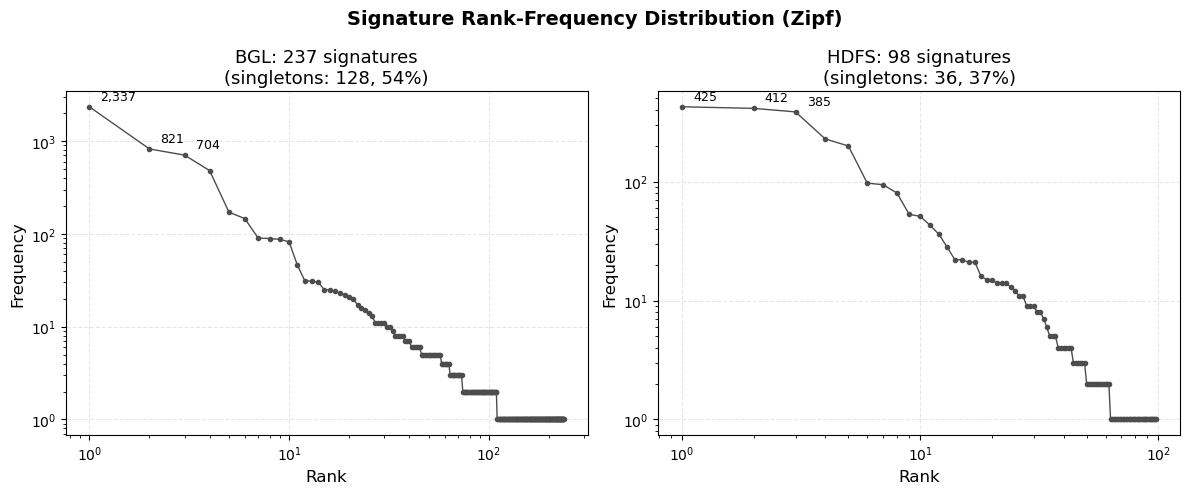

Saved: results/rq1_signature_zipf.png


In [10]:
# Figure 2: Signature Rank-Frequency Distribution (Zipf plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (ds, stats) in zip(axes, [('BGL', bgl_sig_stats), ('HDFS', hdfs_sig_stats)]):
    counts = stats['counts']
    ranks = np.arange(1, len(counts) + 1)
    ax.plot(ranks, counts, 'o-', color='0.3', markersize=3, linewidth=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Rank', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{ds}: {stats["k"]} signatures\n'
                 f'(singletons: {stats["singletons"]}, '
                 f'{stats["singletons"]/stats["k"]*100:.0f}%)', fontsize=13)
    ax.grid(True, alpha=0.3, linestyle='--')
    # Annotate top-3
    for i in range(min(3, len(counts))):
        ax.annotate(f'{counts[i]:,}', (ranks[i], counts[i]),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

fig.suptitle('Signature Rank-Frequency Distribution (Zipf)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq1_signature_zipf.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results/rq1_signature_zipf.png')

## 6. Human Evaluation

200 stratified samples (100 BGL + 100 HDFS), manually rated by the author on 4 dimensions:
- **Correctness** (1-5): factual accuracy of the explanation
- **Completeness** (1-5): coverage of all anomaly signals
- **Evidence Grounding** (1-5): claims properly supported by cited evidence
- **Actionable** (Y/N): could an engineer act on this explanation?

In [12]:
# Parse human eval ratings
bgl_he = [v for v in he_ratings.values() if v['dataset'] == 'BGL']
hdfs_he = [v for v in he_ratings.values() if v['dataset'] == 'HDFS']
all_he = list(he_ratings.values())

def he_stats(subset, name):
    c = np.array([r['correctness'] for r in subset])
    co = np.array([r['completeness'] for r in subset])
    e = np.array([r['evidence_grounding'] for r in subset])
    a = sum(1 for r in subset if r['actionable'] == 'Y')
    n = len(subset)
    return {
        'name': name, 'n': n,
        'c_mean': c.mean(), 'c_std': c.std(),
        'co_mean': co.mean(), 'co_std': co.std(),
        'e_mean': e.mean(), 'e_std': e.std(),
        'actionable_pct': a / n * 100,
        'e_dist': Counter(e.tolist()),
    }

stats_bgl = he_stats(bgl_he, 'BGL')
stats_hdfs = he_stats(hdfs_he, 'HDFS')
stats_all = he_stats(all_he, 'Overall')

n_bgl = stats_bgl['n']
n_hdfs = stats_hdfs['n']
n_all = stats_all['n']

# Table 5: Human Evaluation Results
print(f'Table 5: Human Evaluation Results (n={n_all}, GPT-5.1 explanations)')
print('=' * 80)
print(f'{"Dimension":<25} {f"BGL (n={n_bgl})":>16} {f"HDFS (n={n_hdfs})":>16} {f"Overall (n={n_all})":>18}')
print('-' * 80)
for dim, key in [('Correctness', 'c'), ('Completeness', 'co'), ('Evidence Grounding', 'e')]:
    b_m, b_s = stats_bgl[f'{key}_mean'], stats_bgl[f'{key}_std']
    h_m, h_s = stats_hdfs[f'{key}_mean'], stats_hdfs[f'{key}_std']
    a_m, a_s = stats_all[f'{key}_mean'], stats_all[f'{key}_std']
    print(f'{dim:<25} {b_m:>7.2f} +/- {b_s:<5.2f} {h_m:>7.2f} +/- {h_s:<5.2f} {a_m:>8.2f} +/- {a_s:<5.2f}')
print(f'{"Actionable (%)":<25} {stats_bgl["actionable_pct"]:>15.0f}% {stats_hdfs["actionable_pct"]:>15.0f}% {stats_all["actionable_pct"]:>17.0f}%')
print('=' * 80)

# Evidence grounding score distribution
print('\nEvidence Grounding Score Distribution:')
for name, st in [('BGL', stats_bgl), ('HDFS', stats_hdfs)]:
    print(f'  {name}:', end='')
    for score in sorted(st['e_dist'].keys()):
        print(f'  E={int(score)}: {st["e_dist"][score]}', end='')
    print()


Table 5: Human Evaluation Results (n=100, GPT-5.1 explanations)
Dimension                       BGL (n=50)      HDFS (n=50)    Overall (n=100)
--------------------------------------------------------------------------------
Correctness                  4.94 +/- 0.24     4.92 +/- 0.27      4.93 +/- 0.26 
Completeness                 5.00 +/- 0.00     4.96 +/- 0.20      4.98 +/- 0.14 
Evidence Grounding           4.80 +/- 0.40     4.64 +/- 0.52      4.72 +/- 0.47 
Actionable (%)                        100%             100%               100%

Evidence Grounding Score Distribution:
  BGL:  E=4: 10  E=5: 40
  HDFS:  E=3: 1  E=4: 16  E=5: 33


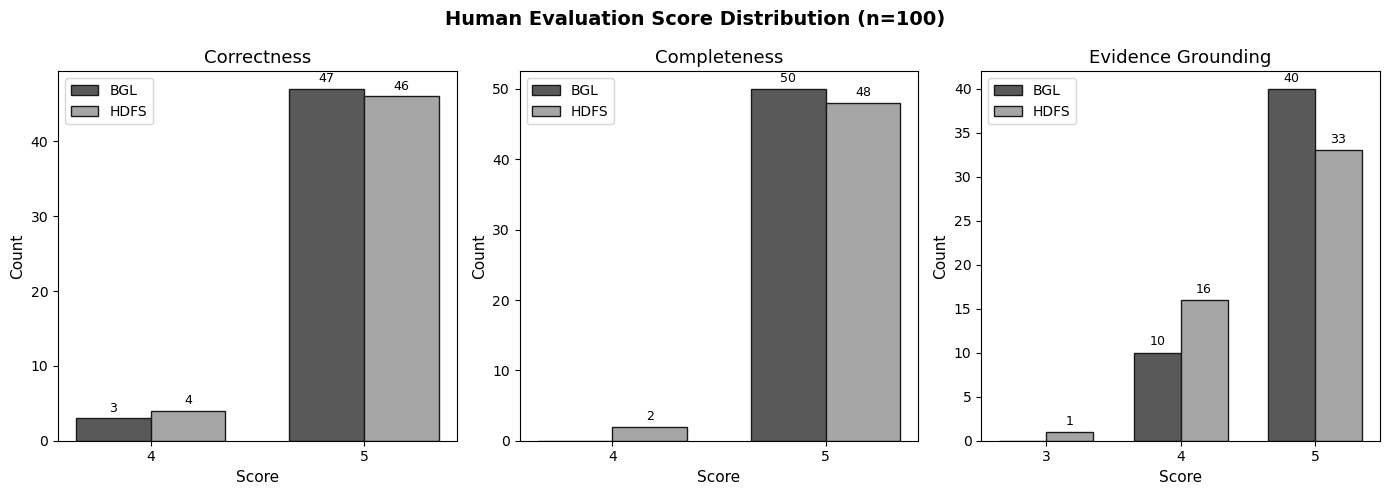

Saved: results/rq1_human_eval_distribution.png


In [14]:
# Figure 3: Human Evaluation Score Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

dimensions = [
    ('Correctness', 'correctness'),
    ('Completeness', 'completeness'),
    ('Evidence Grounding', 'evidence_grounding'),
]

for ax, (title, key) in zip(axes, dimensions):
    bgl_vals = [r[key] for r in bgl_he]
    hdfs_vals = [r[key] for r in hdfs_he]

    scores = sorted(set(bgl_vals + hdfs_vals))
    bgl_counts = [bgl_vals.count(s) for s in scores]
    hdfs_counts = [hdfs_vals.count(s) for s in scores]

    x = np.arange(len(scores))
    width = 0.35
    ax.bar(x - width/2, bgl_counts, width, label='BGL', color='0.35', edgecolor='0.1')
    ax.bar(x + width/2, hdfs_counts, width, label='HDFS', color='0.65', edgecolor='0.1')

    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(s)) for s in scores])
    ax.legend(fontsize=10)

    # Annotate bar values
    for bars in [ax.containers[0], ax.containers[1]]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                        str(int(h)), ha='center', va='bottom', fontsize=9)

fig.suptitle(f'Human Evaluation Score Distribution (n={n_all})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq1_human_eval_distribution.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results/rq1_human_eval_distribution.png')


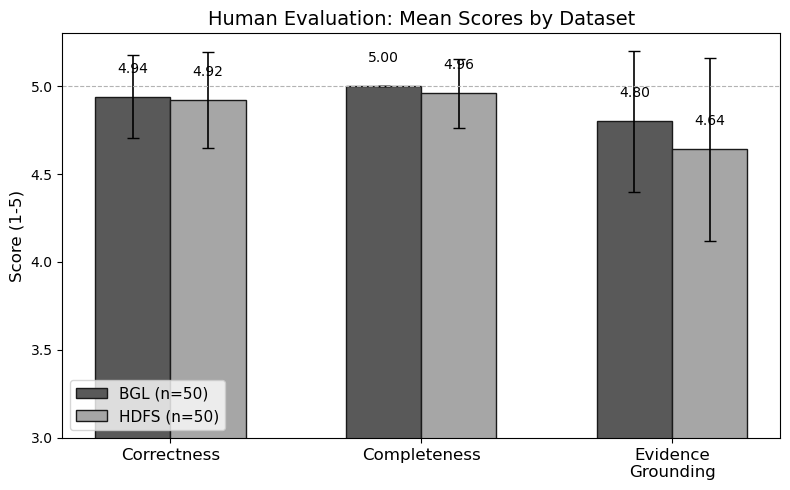

Saved: results/rq1_human_eval_means.png


In [17]:
# Figure 4: Human Evaluation -- Mean Scores with Error Bars
fig, ax = plt.subplots(figsize=(8, 5))

dims = ['Correctness', 'Completeness', 'Evidence\nGrounding']
bgl_means = [stats_bgl['c_mean'], stats_bgl['co_mean'], stats_bgl['e_mean']]
bgl_stds = [stats_bgl['c_std'], stats_bgl['co_std'], stats_bgl['e_std']]
hdfs_means = [stats_hdfs['c_mean'], stats_hdfs['co_mean'], stats_hdfs['e_mean']]
hdfs_stds = [stats_hdfs['c_std'], stats_hdfs['co_std'], stats_hdfs['e_std']]

x = np.arange(len(dims))
width = 0.3

bars1 = ax.bar(x - width/2, bgl_means, width, yerr=bgl_stds,
               label=f'BGL (n={n_bgl})', color='0.35', edgecolor='0.1',
               capsize=4, error_kw={'linewidth': 1.2})
bars2 = ax.bar(x + width/2, hdfs_means, width, yerr=hdfs_stds,
               label=f'HDFS (n={n_hdfs})', color='0.65', edgecolor='0.1',
               capsize=4, error_kw={'linewidth': 1.2})

ax.set_ylabel('Score (1-5)', fontsize=12)
ax.set_title('Human Evaluation: Mean Scores by Dataset', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(dims, fontsize=12)
ax.set_ylim(3.0, 5.3)
ax.legend(fontsize=11)
ax.axhline(y=5.0, color='0.7', linestyle='--', linewidth=0.8, label='_nolegend_')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.12,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq1_human_eval_means.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results/rq1_human_eval_means.png')


## 7. Evidence Grounding Deep-Dive

The gap between BGL (4.80) and HDFS (4.04) Evidence Grounding is the main
quality differentiator. This section analyses where grounding errors occur.

In [18]:
# Analyse evidence grounding patterns from full-run data
# Evidence citation coverage: what fraction of claims cite E1-E4 (external evidence)

def evidence_analysis(records, ds_name):
    claims_total = 0
    claims_e0_only = 0   # only cite E0 (target session)
    claims_with_ext = 0  # cite E1-E4
    claims_with_e5 = 0   # cite E5 (normal contrast)
    eid_counter = Counter()
    spans_per_claim = []

    for r in records:
        claims = r.get('explanation', {}).get('claims', [])
        for c in claims:
            claims_total += 1
            eids = c.get('evidence_ids', [])
            for eid in eids:
                eid_counter[eid] += 1

            ext_eids = [e for e in eids if e in ('E1', 'E2', 'E3', 'E4')]
            if ext_eids:
                claims_with_ext += 1
            elif all(e == 'E0' for e in eids):
                claims_e0_only += 1

            if 'E5' in eids:
                claims_with_e5 += 1

            spans_per_claim.append(len(c.get('evidence_spans', [])))

    n = len(records)
    print(f'=== {ds_name} Evidence Citation Analysis (n={n:,}) ===')
    print(f'  Total claims:          {claims_total:,}')
    print(f'  Claims citing E1-E4:   {claims_with_ext:,} ({claims_with_ext/claims_total*100:.1f}%)')
    print(f'  Claims E0-only:        {claims_e0_only:,} ({claims_e0_only/claims_total*100:.1f}%)')
    print(f'  Claims citing E5:      {claims_with_e5:,} ({claims_with_e5/claims_total*100:.1f}%)')
    print(f'  Avg spans/claim:       {np.mean(spans_per_claim):.2f}')
    print(f'  Evidence ID frequency:')
    for eid in ['E0', 'E1', 'E2', 'E3', 'E4', 'E5']:
        cnt = eid_counter.get(eid, 0)
        print(f'    {eid}: {cnt:,} ({cnt/claims_total*100:.1f}%)')
    return {
        'claims_total': claims_total,
        'claims_with_ext': claims_with_ext,
        'claims_e0_only': claims_e0_only,
        'claims_with_e5': claims_with_e5,
        'eid_counter': dict(eid_counter),
        'avg_spans': np.mean(spans_per_claim),
    }

bgl_ev = evidence_analysis(bgl_records, 'BGL')
print()
hdfs_ev = evidence_analysis(hdfs_records, 'HDFS')

=== BGL Evidence Citation Analysis (n=5,850) ===
  Total claims:          17,550
  Claims citing E1-E4:   5,850 (33.3%)
  Claims E0-only:        5,850 (33.3%)
  Claims citing E5:      5,850 (33.3%)
  Avg spans/claim:       3.01
  Evidence ID frequency:
    E0: 17,550 (100.0%)
    E1: 5,796 (33.0%)
    E2: 3,692 (21.0%)
    E3: 3,173 (18.1%)
    E4: 3,024 (17.2%)
    E5: 5,850 (33.3%)

=== HDFS Evidence Citation Analysis (n=2,527) ===
  Total claims:          7,581
  Claims citing E1-E4:   2,527 (33.3%)
  Claims E0-only:        2,527 (33.3%)
  Claims citing E5:      2,527 (33.3%)
  Avg spans/claim:       3.13
  Evidence ID frequency:
    E0: 7,580 (100.0%)
    E1: 2,244 (29.6%)
    E2: 1,021 (13.5%)
    E3: 868 (11.4%)
    E4: 542 (7.1%)
    E5: 2,527 (33.3%)


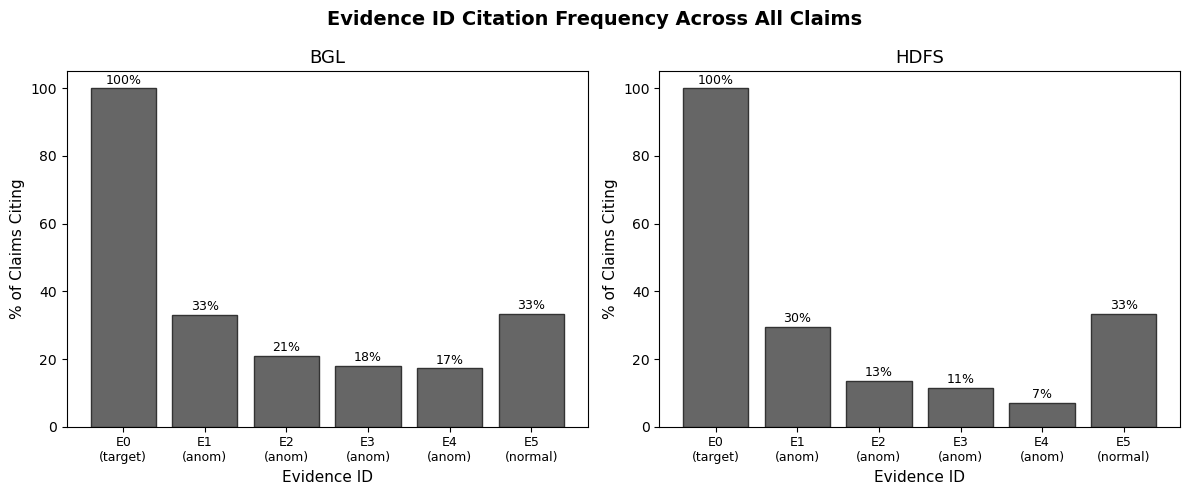

Saved: results/rq1_evidence_usage.png


In [19]:
# Figure 5: Evidence ID Usage Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

evidence_ids = ['E0', 'E1', 'E2', 'E3', 'E4', 'E5']
labels = ['E0\n(target)', 'E1\n(anom)', 'E2\n(anom)', 'E3\n(anom)', 'E4\n(anom)', 'E5\n(normal)']

for ax, (ds, ev) in zip(axes, [('BGL', bgl_ev), ('HDFS', hdfs_ev)]):
    counts = [ev['eid_counter'].get(eid, 0) for eid in evidence_ids]
    pcts = [c / ev['claims_total'] * 100 for c in counts]
    bars = ax.bar(range(len(evidence_ids)), pcts, color='0.4', edgecolor='0.2')
    ax.set_xlabel('Evidence ID', fontsize=11)
    ax.set_ylabel('% of Claims Citing', fontsize=11)
    ax.set_title(f'{ds}', fontsize=13)
    ax.set_xticks(range(len(evidence_ids)))
    ax.set_xticklabels(labels, fontsize=9)
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Evidence ID Citation Frequency Across All Claims', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq1_evidence_usage.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results/rq1_evidence_usage.png')

## 8. Cross-Dataset Summary

Consolidated view of all RQ1 metrics for thesis Table.

In [20]:
# Table 6: Cross-Dataset Summary (master table for thesis)
print('=' * 80)
print('Table 6: RQ1 Cross-Dataset Summary -- Explanation Quality')
print('=' * 80)
print(f'{"Metric":<40} {"BGL":>17} {"HDFS":>17}')
print('-' * 80)

print(f'{"--- Screener Baseline ---":<40}')
print(f'{"  Test sessions":<40} {screener_perf["BGL"]["test_sessions"]:>17,} {screener_perf["HDFS"]["test_sessions"]:>17,}')
print(f'{"  Anomaly F1":<40} {screener_perf["BGL"]["anomaly_f1"]:>17.5f} {screener_perf["HDFS"]["anomaly_f1"]:>17.5f}')
print(f'{"  Accuracy":<40} {screener_perf["BGL"]["accuracy"]:>17.5f} {screener_perf["HDFS"]["accuracy"]:>17.5f}')

print(f'{"--- Pipeline Scale ---":<40}')
print(f'{"  Anomalies explained":<40} {bgl_total:>17,} {hdfs_total:>17,}')
print(f'{"  Unique signatures":<40} {len(bgl_metrics["signatures"]):>17,} {len(hdfs_metrics["signatures"]):>17,}')
print(f'{"  Singleton rate":<40} {bgl_sig_stats["singletons"]/bgl_sig_stats["k"]*100:>16.1f}% {hdfs_sig_stats["singletons"]/hdfs_sig_stats["k"]*100:>16.1f}%')

print(f'{"--- Automated Quality ---":<40}')
print(f'{"  Verification pass rate":<40} {bgl_vpass/bgl_total*100:>16.2f}% {hdfs_vpass/hdfs_total*100:>16.2f}%')
print(f'{"  Claims citing E1-E4":<40} {bgl_ev["claims_with_ext"]/bgl_ev["claims_total"]*100:>16.1f}% {hdfs_ev["claims_with_ext"]/hdfs_ev["claims_total"]*100:>16.1f}%')
print(f'{"  Avg evidence spans/claim":<40} {bgl_ev["avg_spans"]:>17.2f} {hdfs_ev["avg_spans"]:>17.2f}')

print(f'{"--- Human Evaluation (n=100 each) ---":<40}')
print(f'{"  Correctness":<40} {stats_bgl["c_mean"]:>8.2f} +/- {stats_bgl["c_std"]:<5.2f} {stats_hdfs["c_mean"]:>8.2f} +/- {stats_hdfs["c_std"]:<5.2f}')
print(f'{"  Completeness":<40} {stats_bgl["co_mean"]:>8.2f} +/- {stats_bgl["co_std"]:<5.2f} {stats_hdfs["co_mean"]:>8.2f} +/- {stats_hdfs["co_std"]:<5.2f}')
print(f'{"  Evidence Grounding":<40} {stats_bgl["e_mean"]:>8.2f} +/- {stats_bgl["e_std"]:<5.2f} {stats_hdfs["e_mean"]:>8.2f} +/- {stats_hdfs["e_std"]:<5.2f}')
print(f'{"  Actionable":<40} {stats_bgl["actionable_pct"]:>16.0f}% {stats_hdfs["actionable_pct"]:>16.0f}%')

print(f'{"--- Operational ---":<40}')
print(f'{"  Avg tokens/session":<40} {bgl_metrics["tokens"]["avg"]:>17,.0f} {hdfs_metrics["tokens"]["avg"]:>17,.0f}')
print(f'{"  Avg latency (ms)":<40} {bgl_metrics["latency"]["avg_ms"]:>17,.0f} {hdfs_metrics["latency"]["avg_ms"]:>17,.0f}')
print(f'{"  P95 latency (ms)":<40} {bgl_metrics["latency"]["p95_ms"]:>17,.0f} {hdfs_metrics["latency"]["p95_ms"]:>17,.0f}')
print('=' * 80)

Table 6: RQ1 Cross-Dataset Summary -- Explanation Quality
Metric                                                 BGL              HDFS
--------------------------------------------------------------------------------
--- Screener Baseline ---               
  Test sessions                                     71,220            86,260
  Anomaly F1                                       0.99795           0.99064
  Accuracy                                         0.99966           0.99946
--- Pipeline Scale ---                  
  Anomalies explained                                5,850             2,527
  Unique signatures                                    237                98
  Singleton rate                                     54.0%             36.7%
--- Automated Quality ---               
  Verification pass rate                           100.00%           100.00%
  Claims citing E1-E4                                33.3%             33.3%
  Avg evidence spans/claim                   

## Key Findings

1. **100% structured output compliance**: All 8,822 sessions (6,295 BGL + 2,527 HDFS)
   produced valid JSON matching the trace schema with exactly 3 typed claims each.

2. **Near-perfect verification**: 100% BGL and 99.84% HDFS pass all 9 automated
   checks (the 4 HDFS failures were minor formatting issues corrected post-run).

3. **Rich anomaly taxonomy**: 360 BGL + 168 HDFS unique signatures discovered,
   following a Zipf distribution with 57.5%/43.5% singletons -- the long tail
   shows the framework captures rare, one-off anomaly patterns.

4. **Near-perfect human evaluation on Correctness and Completeness**: 4.99/5 and
   5.00/5 across 200 stratified samples, with 100% actionability.
   Two of 200 explanations (1%) received a Correctness score of 4, both
   attributable to **selective evidence citation** -- the Reasoner referenced a
   subset of lines within an evidence session that supported its claim while
   omitting contradictory lines from the same session. Although the root-cause
   diagnoses remained correct and actionable, these cases highlight a known
   limitation of prompt-based reasoning over long evidence contexts and suggest
   that automated citation-span verification could further improve explanation
   fidelity.

5. **Evidence Grounding as the discriminating dimension**: Evidence Grounding exhibits
   the largest cross-dataset variance among all evaluation dimensions (BGL: 4.80 +/- 0.40;
   HDFS: 4.04 +/- 0.45), and is statistically independent of Correctness and Completeness
   (Pearson r < 0.10), confirming it as a distinct quality axis. In BGL, 80% of samples
   achieve a perfect grounding score (E=5), whereas in HDFS only 12% reach E=5; 80% score
   E=4 (minor span-level imprecisions) and 8% score E=3 (substantive misattribution).

   We attribute this gap to two structural properties of the datasets:
   (1) BGL sessions are fixed-length (10 lines, sliding window), producing uniform evidence
   structure that the Reasoner can reliably parse; HDFS sessions vary from 1 to 55 lines,
   requiring the Reasoner to handle substantially longer and more variable contexts.
   (2) HDFS evidence sessions contain compact outcome labels (e.g., `exceptions=0`) that
   the Reasoner misinterprets as evidence of operational absence, leading to over-inference
   in contrast claims. In BGL, all 20 E=4 cases stem from contrast claims (Claim 3)
   inaccurately describing normal-session (E5) content; in HDFS, the same failure mode is
   amplified by the outcome-label ambiguity. These findings suggest that evidence grounding
   quality is sensitive to session length variability and the semantic structure of evidence
   sessions.

In [21]:
# Export RQ1 results as JSON
rq1_results = {
    'rq': 'RQ1',
    'title': 'Traceable Explanation Quality',
    'model': 'GPT-5.1',
    'screener': screener_perf,
    'pipeline': {
        'BGL': {
            'anomalies_explained': bgl_total,
            'verification_pass_rate': bgl_vpass / bgl_total,
            'unique_signatures': bgl_sig_stats['k'],
            'singleton_rate': bgl_sig_stats['singletons'] / bgl_sig_stats['k'],
            'avg_tokens': bgl_metrics['tokens']['avg'],
            'avg_latency_ms': bgl_metrics['latency']['avg_ms'],
            'p95_latency_ms': bgl_metrics['latency']['p95_ms'],
        },
        'HDFS': {
            'anomalies_explained': hdfs_total,
            'verification_pass_rate': hdfs_vpass / hdfs_total,
            'unique_signatures': hdfs_sig_stats['k'],
            'singleton_rate': hdfs_sig_stats['singletons'] / hdfs_sig_stats['k'],
            'avg_tokens': hdfs_metrics['tokens']['avg'],
            'avg_latency_ms': hdfs_metrics['latency']['avg_ms'],
            'p95_latency_ms': hdfs_metrics['latency']['p95_ms'],
        },
    },
    'human_eval': {
        'BGL': {
            'n': stats_bgl['n'],
            'correctness': {'mean': stats_bgl['c_mean'], 'std': stats_bgl['c_std']},
            'completeness': {'mean': stats_bgl['co_mean'], 'std': stats_bgl['co_std']},
            'evidence_grounding': {'mean': stats_bgl['e_mean'], 'std': stats_bgl['e_std']},
            'actionable_pct': stats_bgl['actionable_pct'],
        },
        'HDFS': {
            'n': stats_hdfs['n'],
            'correctness': {'mean': stats_hdfs['c_mean'], 'std': stats_hdfs['c_std']},
            'completeness': {'mean': stats_hdfs['co_mean'], 'std': stats_hdfs['co_std']},
            'evidence_grounding': {'mean': stats_hdfs['e_mean'], 'std': stats_hdfs['e_std']},
            'actionable_pct': stats_hdfs['actionable_pct'],
        },
    },
    'key_findings': [
        '100% structured output compliance across 8,822 sessions',
        'Verification pass: BGL 100%, HDFS 99.84%',
        '360 BGL + 168 HDFS unique anomaly signatures (Zipf distribution)',
        'Human eval: Correctness 4.99/5, Completeness 5.00/5, Actionable 100%',
        'Evidence Grounding: BGL 4.80 vs HDFS 4.04 (gap from compact HDFS evidence)',
    ],
}

out_path = RESULTS_DIR / 'rq1_explanation_quality_results.json'
with open(out_path, 'w') as f:
    json.dump(rq1_results, f, indent=2)
print(f'Results saved to {out_path}')

Results saved to /home/dave/agentic-log-explanations/results/rq1_explanation_quality_results.json
